Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Imagen cargada correctamente desde Google Drive!


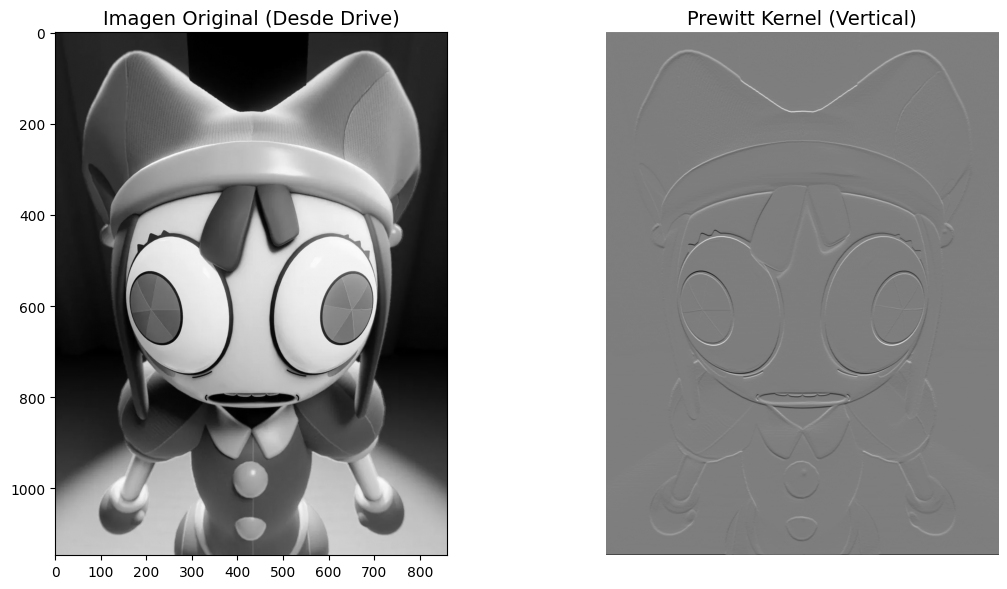

In [5]:
# =====================================================================
# CLASE: Redes Convolucionales - Introducción a Kernels (Filtros)
# =====================================================================

# 1. Conectar Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Asegúrate de subir una imagen (por ejemplo, 'mi_imagen.jpg') a tu Drive.
# Modifica la siguiente ruta con la ubicación real de tu archivo en Drive.
ruta_imagen_drive = '/content/drive/MyDrive/CNN/ramirez.jpg'

# 2. Importar las librerías necesarias
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

try:
    # 3. Cargar la imagen desde Drive y convertirla a escala de grises
    # Nota didáctica: Usamos escala de grises (1 solo canal) para facilitar la comprensión matemática de la convolución.
    imagen_pil = Image.open(ruta_imagen_drive).convert('L')
    print("¡Imagen cargada correctamente desde Google Drive!")
except FileNotFoundError:
    print(f"Error: No se encontró ningún archivo en la ruta: {ruta_imagen_drive}")
    print("Por favor, verifica el nombre y la extensión del archivo en tu Google Drive.")

# 4. Preprocesamiento: Convertir la imagen en un Tensor de PyTorch
# Transformamos la imagen a un tensor con valores en el rango [0, 1]
transformacion = transforms.ToTensor()
imagen_tensor = transformacion(imagen_pil) # Dimensiones resultantes: [Canales, Alto, Ancho] -> [1, H, W]

# PyTorch requiere que el lote (batch) tenga la forma: [Batch_Size, Canales, Alto, Ancho]
imagen_tensor = imagen_tensor.unsqueeze(0) # Añadimos la dimensión del lote -> [1, 1, H, W]

# 5. Definición del Kernel de Identidad (3x3)
# Explicación: Matriz donde todos los elementos son 0 excepto el centro que es 1.
kernel_identidad = np.array([[-1, -2, -1,],
                             [0, 0, 0],
                            [1, 2, 1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

# 6. Aplicar la Operación de Convolución
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

# 7. Postprocesamiento: Remover las dimensiones extras para poder graficar
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
img_original_np = imagen_tensor.squeeze().numpy()
img_salida_np = imagen_convolucionada.squeeze().numpy()

# 8. Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)


# Subplot 2: Imagen Filtrada
axes[1].imshow(img_salida_np, cmap='gray')
axes[1].set_title("Prewitt Kernel (Vertical)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()